In [3]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [4]:
keras.utils.set_random_seed(42)

In [5]:
df=pd.read_csv('cleaned_data.csv')
df.head()

,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...


In [6]:
df=df.dropna(subset=['label'])
df['text']=df['text'].fillna('').str.lower().str.strip()

In [7]:
X=df['text']
y=df['label']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [9]:
max_words=10000
max_len=100

tokenizer=Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

In [11]:
tokenizer.fit_on_texts(X_train)


train_sequence=tokenizer.texts_to_sequences(X_train)
test_sequence=tokenizer.texts_to_sequences(X_test)

In [12]:
X_train_pad=pad_sequences(
    train_sequence,
    maxlen=max_len,
    padding="post",
    truncating="post"
)
X_test_pad=pad_sequences(
    test_sequence,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

In [15]:
y_train_np=y_train.to_numpy(dtype=np.float32)
y_test_np=y_test.to_numpy(dtype=np.float32)

In [16]:
vocab_size=min(
    max_words,
    len(tokenizer.word_index)+1
)

print("Vocabulary size:", vocab_size)
print("Training shape:", X_train_pad.shape)
print("Training word index:", tokenizer.word_index)

Vocabulary size: 10000
Training shape: (2398, 100)
Training word index: {'<OOV>': 1, 'ect': 2, 'hou': 3, 'enron': 4, '2000': 5, 'com': 6, '3': 7, 'please': 8, '1': 9, '2': 10, '00': 11, 'gas': 12, 'subject': 13, 'e': 14, 'deal': 15, 'meter': 16, 'http': 17, 'cc': 18, '000': 19, 'pm': 20, '10': 21, '0': 22, '5': 23, 'company': 24, '4': 25, 'may': 26, 'new': 27, 'get': 28, 'daren': 29, 'hpl': 30, 'thanks': 31, 'information': 32, 'corp': 33, '2001': 34, 'price': 35, '7': 36, 'need': 37, '01': 38, 'know': 39, '99': 40, 'us': 41, 'www': 42, 'email': 43, '9': 44, 'see': 45, '11': 46, 'one': 47, '12': 48, 'time': 49, '6': 50, 'j': 51, '03': 52, 'forwarded': 53, '8': 54, 'would': 55, 'mail': 56, 'p': 57, 'statements': 58, 'l': 59, 'message': 60, 'font': 61, 'mmbtu': 62, 'farmer': 63, '20': 64, 'day': 65, 'nbsp': 66, '30': 67, 'let': 68, 'b': 69, '15': 70, '02': 71, 'also': 72, 'attached': 73, 'th': 74, 'month': 75, 'xls': 76, 'x': 77, 'energy': 78, '04': 79, 'like': 80, '09': 81, 'c': 82, 'inc

In [ ]:
model = keras.Sequential(
    [
        layers.Input(shape=(max_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True),
        layers.LSTM(16),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,713 (1.23 MB)

 Trainable params: 323,713 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stoppping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [25]:
history=model.fit(
    X_train_pad,
    y_train_np,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stoppping],
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.7826 - loss: 0.5658 - val_accuracy: 0.9021 - val_loss: 0.2519
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9458 - loss: 0.1619 - val_accuracy: 0.9438 - val_loss: 0.1450
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9812 - loss: 0.0688 - val_accuracy: 0.9333 - val_loss: 0.2109
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.9917 - loss: 0.0443 - val_accuracy: 0.9625 - val_loss: 0.1059
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.9969 - loss: 0.0238 - val_accuracy: 0.9792 - val_loss: 0.0825
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9984 - loss: 0.0161 - val_accuracy: 0.9667 - val_loss: 0.0968
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9990 - loss: 0.0109 - val_accuracy: 0.9729 - val_loss: 0.0934
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9995 - loss: 0.0070 - val_accuracy: 0.9

In [27]:
test_loss,test_accuracy=model.evaluate(
    X_test_pad,
    y_test_np,
    verbose=0
)


print("\nTest loss:", test_loss*100)
print("Test accuracy:", test_accuracy*100)


Test loss: 10.566025972366333
Test accuracy: 97.66666889190674


In [30]:
y_prob=model.predict(X_test_pad,verbose=0).ravel()
y_pred=(y_prob>=0.5).astype(int)

print(classification_report(
    y_test_np,
    y_pred,
    target_names=['Ham','Spam'],
    zero_division=0
))

              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       315
        Spam       0.96      0.99      0.98       285

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



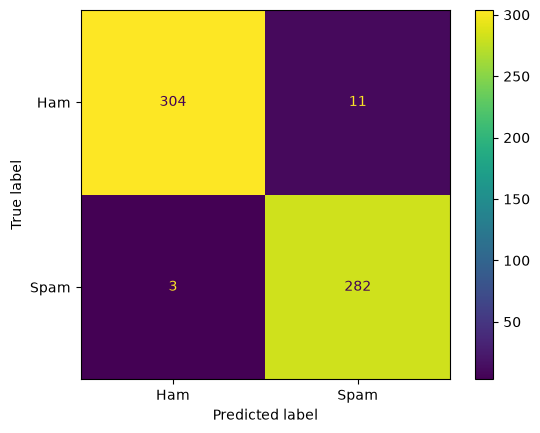

In [31]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_np, y_pred),
    display_labels=["Ham", "Spam"]
).plot()

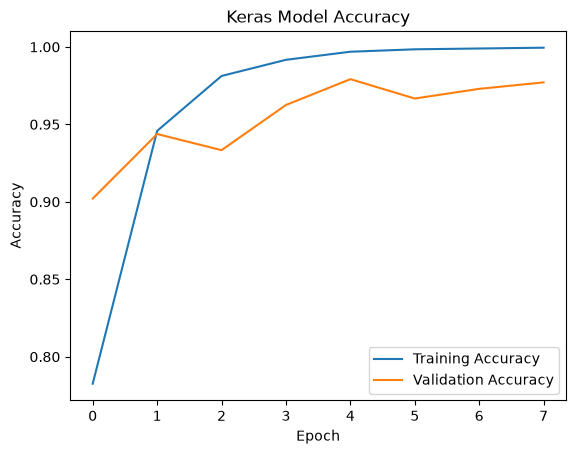


Message: Congratulations! You have won a free prize
Prediction: Spam
Spam probability: 0.9362

Message: Hey, are we meeting today?
Prediction: Spam
Spam probability: 0.7682


In [32]:
# 13. Plot accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Keras Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 14. Test a new SMS
def predict_sms(message):
    sequence = tokenizer.texts_to_sequences([message.lower()])
    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    probability = float(model.predict(padded, verbose=0)[0, 0])

    print("\nMessage:", message)
    print("Prediction:", "Spam" if probability >= 0.5 else "Ham")
    print("Spam probability:", round(probability, 4))


predict_sms("Congratulations! You have won a free prize")
predict_sms("Hey, are we meeting today?")
